Loading metrics...

Metrics head:
+-------+-----------+--------------------+--------------------+--------------------+--------------------+
| Model |   Coin    |        RMSE        |        MAE         |        MAPE        |         R2         |
+-------+-----------+--------------------+--------------------+--------------------+--------------------+
| ARIMA |  BCH-USD  |  89.0197732633766  | 77.74462556185787  | 17.93435485004928  | -3.214389043853317 |
| ARIMA |  BTC-USD  | 19163.160843165748 | 18195.38602311644  | 17.422143245564893 | -9.157106266255028 |
| ARIMA | LINK-USD  | 2.298501475552696  | 1.938667075274742  | 12.780902538784677 | -2.133505368719649 |
| ARIMA | STETH-USD | 817.5880086966596  | 740.7122802734375  | 30.00897910234676  | -4.554230618371288 |
| LSTM  |  BCH-USD  | 24.84247609542874  | 19.692427838434934 | 4.476932830605338  | 0.5701539116360046 |
| LSTM  |  BTC-USD  | 3171.958443252315  | 2522.4978227459014 | 2.388508368519738  | 0.3089834928007071 |
| LSTM  | LI

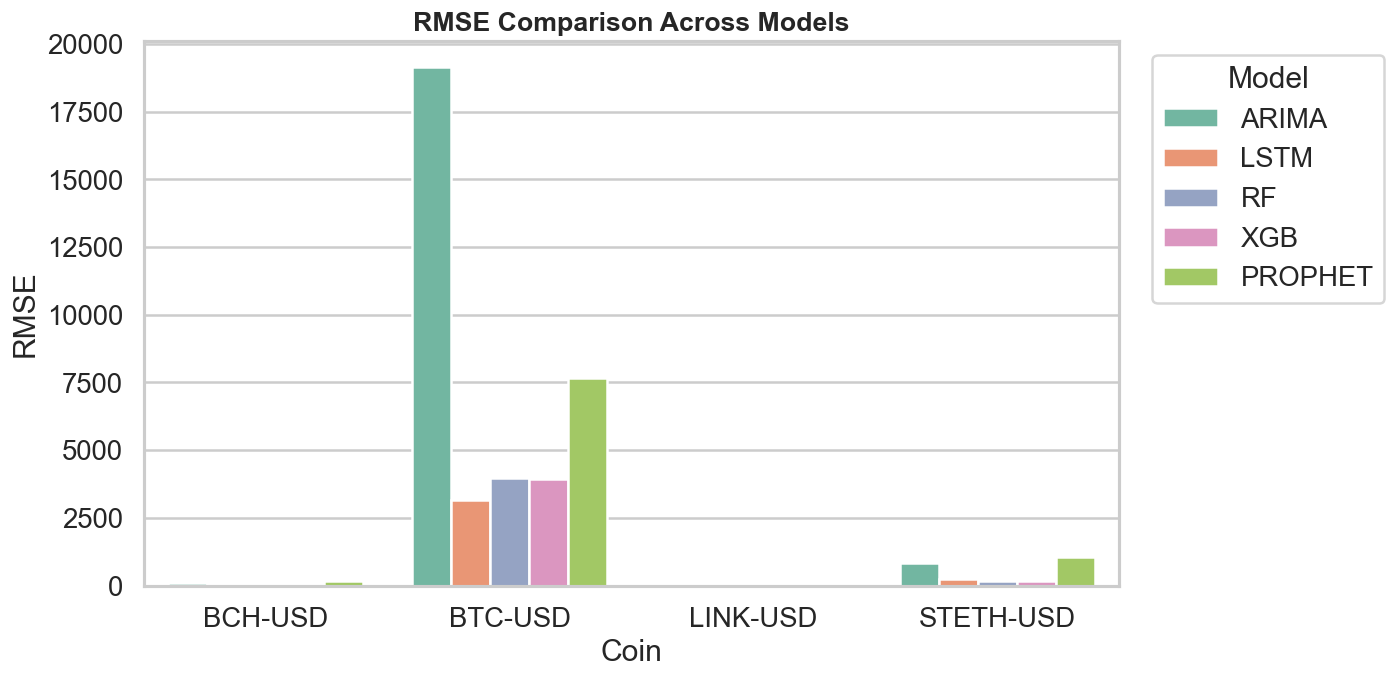

Saved figure: ../results/figures/grouped_MAE.png


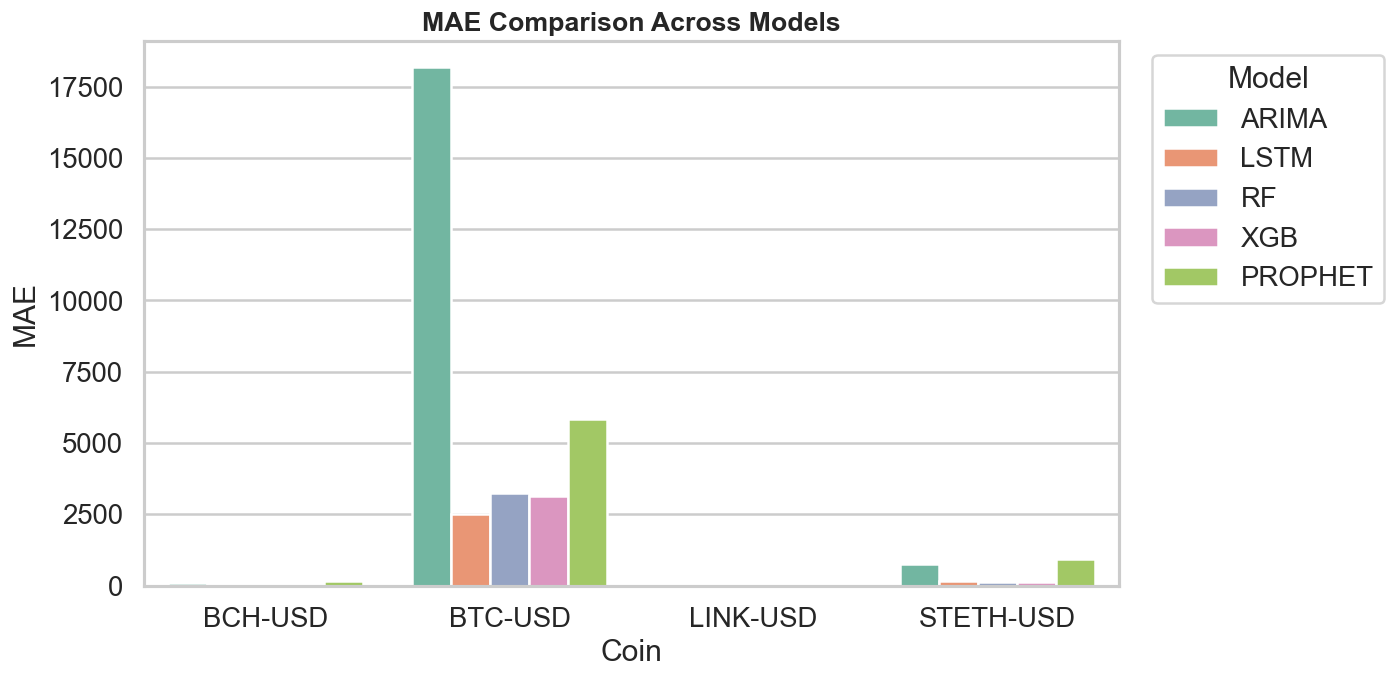

Saved figure: ../results/figures/grouped_MAPE.png


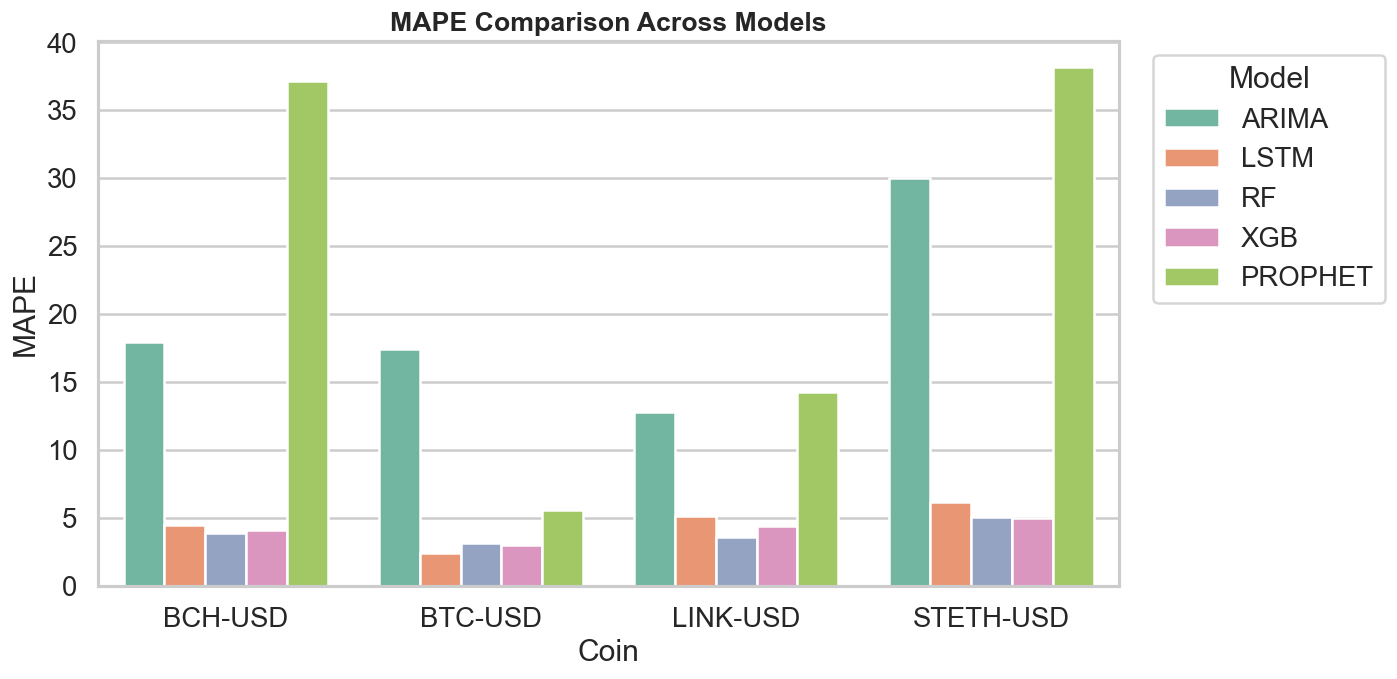

Saved figure: ../results/figures/grouped_R2.png


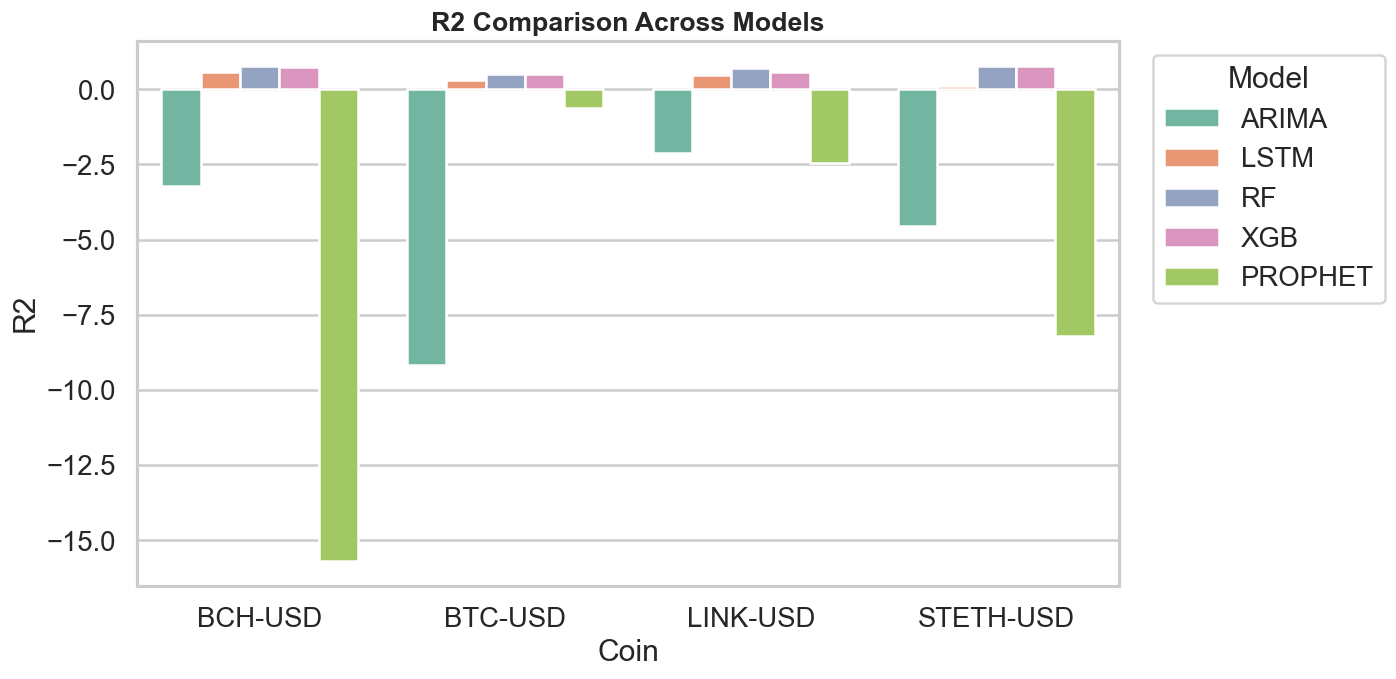

Saved figure: ../results/figures/heatmap_rmse.png


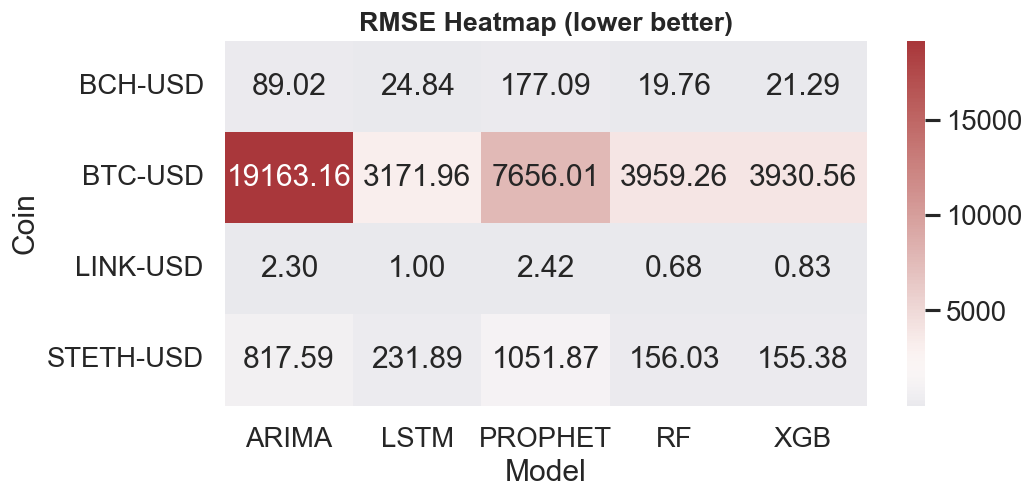

Saved figure: ../results/figures/violin_ae.png


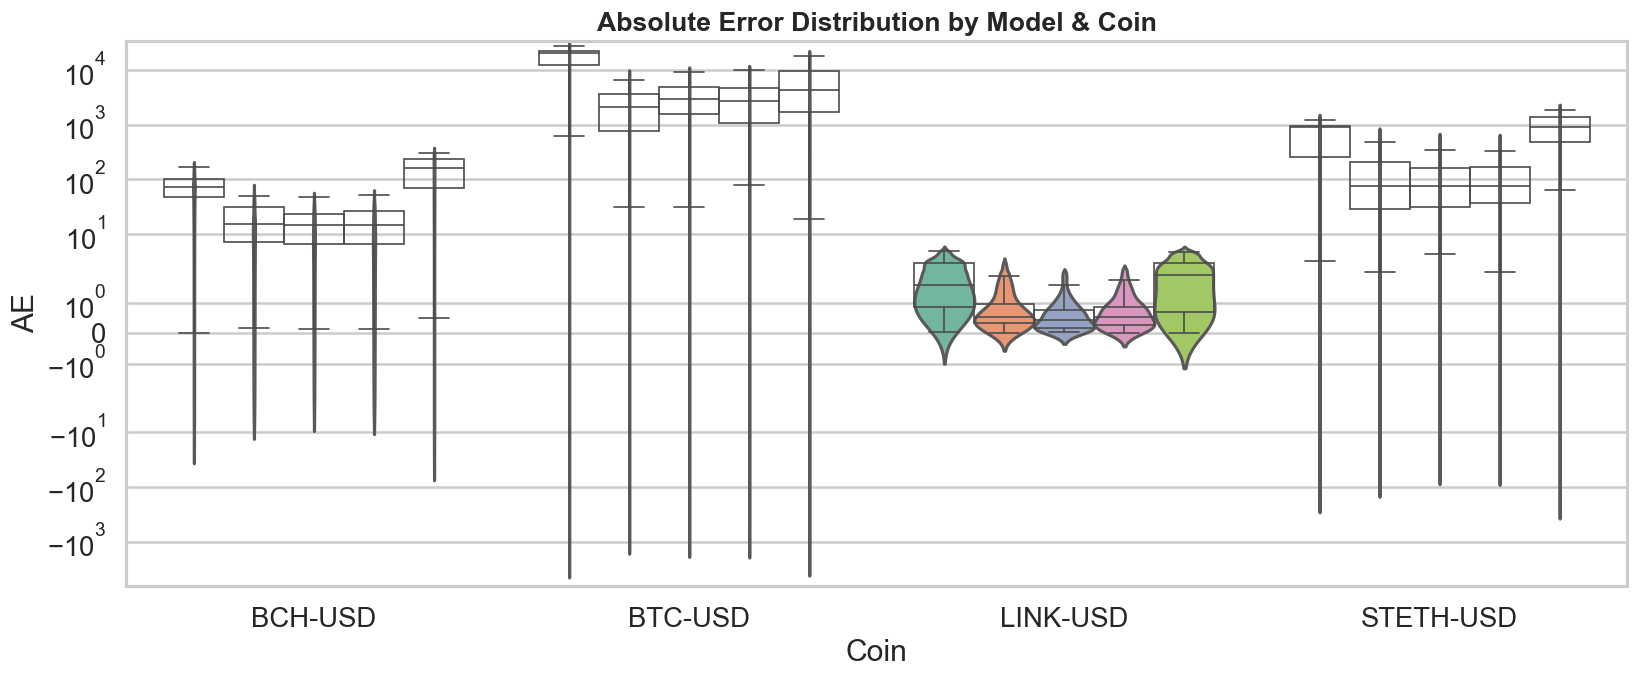

/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_88774/3066308128.py:213: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=preds_df, x='Model', y='AE', palette='Set3', ax=ax)


Saved figure: ../results/figures/box_ae_models.png


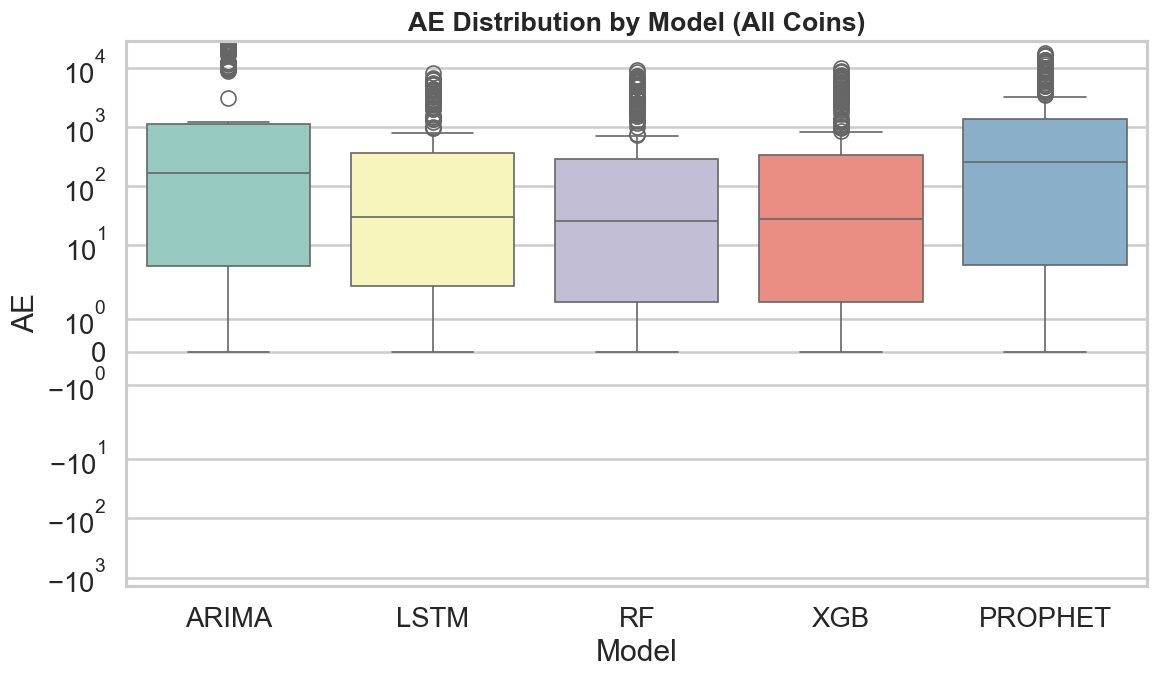

Saved figure: ../results/figures/radar_models.png


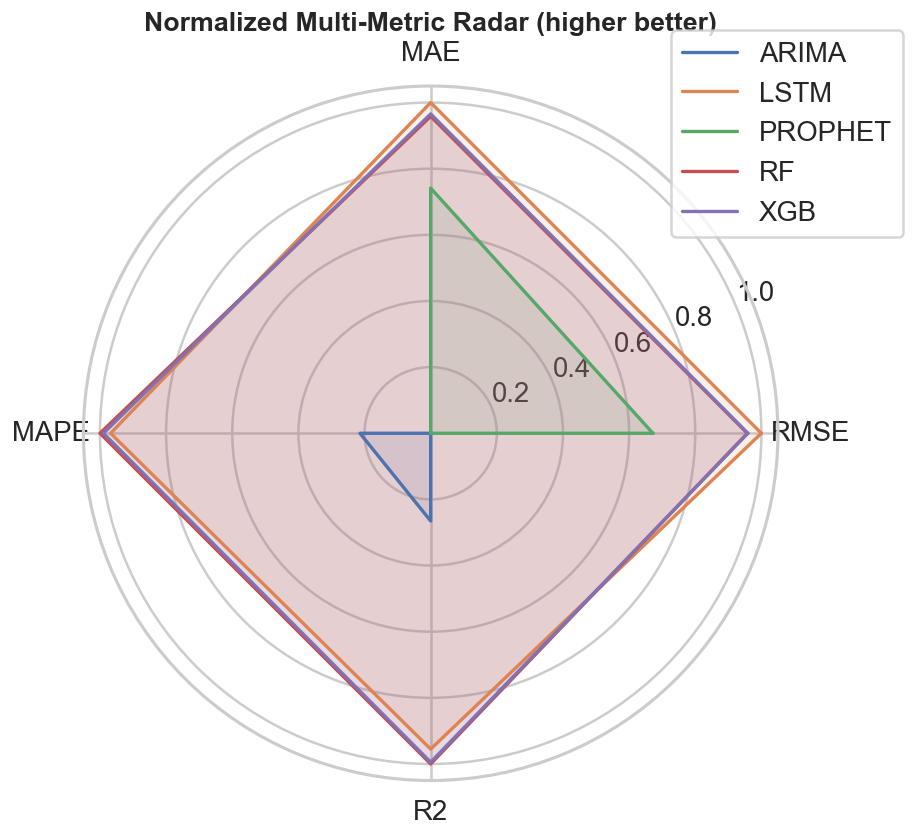

No overlapping prediction dates for BTC-USD between lstm and xgb

Statistical comparison summary (Top-2 by RMSE per coin):
+-----------+--------+--------+--------------------+--------------------+----------------------+----------------------+---------------------+----------------------+----------------------+
|   Coin    | Model1 | Model2 |      AE1_mean      |      AE2_mean      |      wilcoxon_p      |       ttest_p        |      mean_diff      |     boot_ci_low      |     boot_ci_high     |
+-----------+--------+--------+--------------------+--------------------+----------------------+----------------------+---------------------+----------------------+----------------------+
|  BCH-USD  |   RF   |  XGB   | 16.19809413062202  | 17.000815353054474 | 0.23417257495220345  | 0.22280530670778048  | -0.8027212224324506 |  -2.024911310540088  | 0.41955385848914056  |
| LINK-USD  |   RF   |  XGB   | 0.5229027300350374 | 0.6481359509480794 | 0.010843292846665395 | 0.005168030756896291 | -0.12

In [1]:
# ===========================
# Professional Comparison_Analysis
# ===========================
# Run in your notebook environment (assumes working dir same as your tree).
# Requires: pandas, numpy, matplotlib, seaborn, scipy, tabulate, sklearn
# Install any missing packages via pip if needed.

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, ttest_rel
from sklearn.utils import resample
from tabulate import tabulate
from matplotlib.lines import Line2D

# -------------------------
# Configuration (edit if needed)
# -------------------------
MODEL_NAMES = ['arima', 'lstm', 'rf', 'xgb', 'prophet']
COINS = ['BCH-USD', 'BTC-USD', 'LINK-USD', 'STETH-USD']
METRICS_DIR = '../results/'
SIGNAL_DIR = '../results/Signal_Test/'
FIG_DIR = os.path.join(METRICS_DIR, 'figures')

os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 120

# -------------------------
# Utility loaders (robust)
# -------------------------
def load_metrics_files(metrics_dir=METRICS_DIR):
    """Collect metrics CSVs named like <model>_metrics_<coin>.csv"""
    frames = []
    for m in MODEL_NAMES:
        for c in COINS:
            path = os.path.join(metrics_dir, f"{m}_metrics_{c}.csv")
            if os.path.exists(path):
                df = pd.read_csv(path)
                # fill missing metric columns if any
                for col in ['RMSE','MAE','MAPE','R2']:
                    if col not in df.columns:
                        df[col] = np.nan
                df = df.iloc[0:1].copy()  # ensure single-row
                df['Model'] = m.upper()
                df['Coin'] = c
                frames.append(df[['Model','Coin','RMSE','MAE','MAPE','R2']])
            else:
                # ⚠️ Add placeholder row so missing models still appear
                print(f"⚠️ Metrics missing: {path}, adding placeholder")
                placeholder = pd.DataFrame([{
                    'Model': m.upper(),
                    'Coin': c,
                    'RMSE': np.nan,
                    'MAE': np.nan,
                    'MAPE': np.nan,
                    'R2': np.nan
                }])
                frames.append(placeholder)

    if len(frames) == 0:
        raise FileNotFoundError("No metrics files found in metrics directory.")
    metrics = pd.concat(frames, ignore_index=True)
    return metrics

def load_prediction_file_variants(model, coin):
    """Search both METRICS_DIR and SIGNAL_DIR for predictions for (model,coin).
       Return DataFrame or None. Accept many naming variants used in your repo."""
    candidates = []
    # Known pattern in your tree: predictions_<model>_<coin>.csv inside SIGNAL_DIR
    candidates += glob.glob(os.path.join(SIGNAL_DIR, f"predictions_{model}_*{coin}*.csv"))
    # Some notebooks may have used other patterns in results/
    candidates += glob.glob(os.path.join(METRICS_DIR, f"predictions_{model}_*{coin}*.csv"))
    # Also try <model>_predictions_<coin> or <model>_<coin>_predictions
    candidates += glob.glob(os.path.join(SIGNAL_DIR, f"*{model}*{coin}*.csv"))
    candidates = list(dict.fromkeys(candidates))  # unique, preserve order

    for f in candidates:
        try:
            df = pd.read_csv(f)
        except Exception:
            continue
        # Normalize: if Date exists, parse; if Test_Index exists, convert to a pseudo-date
        if 'Date' in df.columns:
            try:
                df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            except Exception:
                df['Date'] = pd.to_datetime(df['Date'].astype(str), errors='coerce')
        elif 'Test_Index' in df.columns:
            # If there's no Date, create a Date-like index by treating Test_Index as integer steps
            df['Date'] = pd.to_datetime(df['Test_Index'], unit='D', origin='unix', errors='coerce')
            # if conversion fails, keep as numeric index
            if df['Date'].isna().all():
                df['Date'] = pd.to_timedelta(df['Test_Index'], unit='D') + pd.Timestamp("1970-01-01")
        # Standardize column names for actual/pred
        colmap = {}
        for c in df.columns:
            lc = c.lower()
            if 'actual' in lc or 'y_true' in lc or 'actuals' in lc or 'y'==lc:
                colmap[c] = 'Actual'
            if 'pred' in lc or 'yhat' in lc or 'forecast' in lc:
                colmap[c] = 'Predicted'
        df = df.rename(columns=colmap)
        if 'Actual' in df.columns and 'Predicted' in df.columns:
            df = df[['Date','Actual','Predicted']].copy()
            df['Model'] = model.upper()
            df['Coin'] = coin
            return df
        # fallback: sometimes columns 'Actual' and 'Predicted' different; attempt heuristics
    return None

# -------------------------
# Load everything
# -------------------------
print("Loading metrics...")
metrics_df = load_metrics_files()
print("\nMetrics head:")
print(tabulate(metrics_df.head(12), headers='keys', tablefmt='pretty', showindex=False))

# Load predictions (for AE series and plots)
predictions = []
for m in MODEL_NAMES:
    for c in COINS:
        pred_df = load_prediction_file_variants(m, c)
        if pred_df is None:
            # print(f"⚠️ Prediction missing for {m} {c}")
            continue
        # drop rows without numeric actual/pred
        pred_df = pred_df.dropna(subset=['Actual','Predicted'])
        # ensure numeric
        pred_df['Actual'] = pd.to_numeric(pred_df['Actual'], errors='coerce')
        pred_df['Predicted'] = pd.to_numeric(pred_df['Predicted'], errors='coerce')
        pred_df = pred_df.dropna(subset=['Actual','Predicted'])
        if pred_df.empty:
            continue
        pred_df.sort_values('Date', inplace=True)
        pred_df.reset_index(drop=True, inplace=True)
        # compute absolute error
        pred_df['AE'] = np.abs(pred_df['Actual'] - pred_df['Predicted'])
        predictions.append(pred_df)

if len(predictions) == 0:
    print("\n⚠️ No prediction CSVs found in SIGNAL_DIR or METRICS_DIR. Visuals limited to metrics only.")
preds_df = pd.concat(predictions, ignore_index=True) if predictions else pd.DataFrame(columns=['Date','Actual','Predicted','AE','Model','Coin'])

# -------------------------
# Compute Additional Aggregates
# -------------------------
# Ensure metrics DF types numeric
for col in ['RMSE','MAE','MAPE','R2']:
    if col in metrics_df.columns:
        metrics_df[col] = pd.to_numeric(metrics_df[col], errors='coerce')

# Compute mean metrics per model (across coins)
mean_metrics = metrics_df.groupby('Model')[['RMSE','MAE','MAPE','R2']].mean().reset_index()

# -------------------------
# Visualization: Aesthetic plots
# -------------------------
def savefig(fig, fname):
    path = os.path.join(FIG_DIR, fname)
    fig.savefig(path, bbox_inches='tight')
    print(f"Saved figure: {path}")

# 1) Grouped bars per metric
def plot_grouped_bars(df, metric):
    fig, ax = plt.subplots(figsize=(12,6))
    order_models = sorted(df['Model'].unique())
    sns.barplot(data=df, x='Coin', y=metric, hue='Model', ax=ax, palette='Set2')
    ax.set_title(f'{metric} Comparison Across Models', fontsize=16, weight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('Coin')
    ax.legend(title='Model', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    savefig(fig, f'grouped_{metric}.png')
    plt.show()

for metric in ['RMSE','MAE','MAPE','R2']:
    if metric in metrics_df.columns:
        plot_grouped_bars(metrics_df, metric)

# 2) Heatmap RMSE (coin x model)
if 'RMSE' in metrics_df.columns:
    pivot = metrics_df.pivot_table(index='Coin', columns='Model', values='RMSE', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(9,4.5))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap='vlag', center=np.nanmean(pivot.values), ax=ax)
    ax.set_title('RMSE Heatmap (lower better)', fontsize=16, weight='bold')
    plt.tight_layout()
    savefig(fig, 'heatmap_rmse.png')
    plt.show()

# 3) Violin + boxplot of Absolute Errors (if predictions available)
if not preds_df.empty:
    fig, ax = plt.subplots(figsize=(14,6))
    sns.violinplot(data=preds_df, x='Coin', y='AE', hue='Model', split=False, inner=None, palette='Set2', ax=ax)
    sns.boxplot(data=preds_df, x='Coin', y='AE', hue='Model', showcaps=True,
                boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':1}, ax=ax)
    # Adjust legend (two legends due to overlay), keep first
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()
    ax.set_yscale('symlog')  # helps visualize heavy tails gracefully
    ax.set_title('Absolute Error Distribution by Model & Coin', fontsize=16, weight='bold')
    plt.tight_layout()
    savefig(fig, 'violin_ae.png')
    plt.show()

# 4) Boxplots of AE across models (aggregated)
if not preds_df.empty:
    fig, ax = plt.subplots(figsize=(10,6))
    sns.boxplot(data=preds_df, x='Model', y='AE', palette='Set3', ax=ax)
    ax.set_title('AE Distribution by Model (All Coins)', fontsize=16, weight='bold')
    ax.set_yscale('symlog')
    plt.tight_layout()
    savefig(fig, 'box_ae_models.png')
    plt.show()

# 5) Radar chart of normalized metrics (higher is better)
def radar_plot_metrics(metrics_df):
    # prepare: invert error metrics so higher is better
    df = metrics_df.copy()
    df_m = df.groupby('Model')[['RMSE','MAE','MAPE','R2']].mean()
    df_m = df_m.dropna(axis=1, how='all')
    # Invert errors
    for c in ['RMSE','MAE','MAPE']:
        if c in df_m.columns:
            df_m[c] = -df_m[c]
    # Normalize each column 0-1
    mini = df_m.min()
    maxi = df_m.max()
    norm = (df_m - mini) / (maxi - mini + 1e-12)
    categories = list(norm.columns)
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    fig = plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)
    for idx, row in norm.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, label=idx, linewidth=2)
        ax.fill(angles, values, alpha=0.12)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_title('Normalized Multi-Metric Radar (higher better)', fontsize=16, weight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.2,1.1))
    plt.tight_layout()
    savefig(fig, 'radar_models.png')
    plt.show()

radar_plot_metrics(metrics_df)

# -------------------------
# Statistical comparisons: Top-2 per coin
# -------------------------
stat_results = []
if not preds_df.empty:
    for coin in COINS:
        # find top-2 by RMSE (lower)
        sub_metrics = metrics_df[metrics_df['Coin'] == coin].dropna(subset=['RMSE'])
        if sub_metrics.shape[0] < 2:
            print(f"Not enough metric rows for coin {coin} to compare.")
            continue
        top2 = sub_metrics.sort_values('RMSE').Model.values[:2]
        m1, m2 = top2[0].lower(), top2[1].lower()
        df1 = load_prediction_file_variants(m1, coin)
        df2 = load_prediction_file_variants(m2, coin)
        if df1 is None or df2 is None:
            print(f"No preds to compare for {coin}: {m1} vs {m2}")
            continue
        # align by Date
        df = pd.merge(df1, df2, on='Date', suffixes=(f'_{m1}', f'_{m2}'))
        if df.empty:
            print(f"No overlapping prediction dates for {coin} between {m1} and {m2}")
            continue
        ae1 = np.abs(df[f'Actual_{m1}'] - df[f'Predicted_{m1}'])
        ae2 = np.abs(df[f'Actual_{m2}'] - df[f'Predicted_{m2}'])
        # Wilcoxon (non-parametric)
        try:
            w_stat, w_p = wilcoxon(ae1, ae2)
        except Exception as e:
            w_stat, w_p = np.nan, np.nan
        # Paired t-test
        try:
            t_stat, t_p = ttest_rel(ae1, ae2)
        except Exception:
            t_stat, t_p = np.nan, np.nan
        # Bootstrap mean diff 95% CI
        diffs = ae1.values - ae2.values
        boots = []
        for _ in range(2000):
            sample = resample(diffs, replace=True, n_samples=len(diffs))
            boots.append(sample.mean())
        low_ci, high_ci = np.percentile(boots, [2.5, 97.5])
        stat_results.append({
            'Coin': coin, 'Model1': m1.upper(), 'Model2': m2.upper(),
            'AE1_mean': ae1.mean(), 'AE2_mean': ae2.mean(),
            'wilcoxon_p': w_p, 'ttest_p': t_p,
            'mean_diff': diffs.mean(), 'boot_ci_low': low_ci, 'boot_ci_high': high_ci
        })

    stat_df = pd.DataFrame(stat_results)
    if not stat_df.empty:
        print("\nStatistical comparison summary (Top-2 by RMSE per coin):")
        print(tabulate(stat_df, headers='keys', tablefmt='pretty', showindex=False))
        stat_df.to_csv(os.path.join(FIG_DIR, 'statistical_comparisons_top2.csv'), index=False)
else:
    stat_df = pd.DataFrame()

# -------------------------
# Ranking, Borda & final winner selection
# -------------------------
# Create ranks per metric per coin: lower better for errors, higher better for R2
rank_rows = []
metrics_for_rank = ['RMSE','MAE','MAPE','R2']
for coin in COINS:
    sub = metrics_df[metrics_df['Coin'] == coin].copy()
    if sub.empty:
        continue
    for metric in metrics_for_rank:
        if metric not in sub.columns:
            continue
        asc = True if metric in ['RMSE','MAE','MAPE'] else False
        sub = sub.dropna(subset=[metric])
        if sub.empty:
            continue
        sub = sub.copy()
        sub['rank'] = sub[metric].rank(ascending=asc, method='min')
        for _, r in sub.iterrows():
            rank_rows.append({'Coin': coin, 'Model': r['Model'], 'Metric': metric, 'Rank': r['rank']})

ranks_df = pd.DataFrame(rank_rows)
# Average rank per Model across coins & metrics
avg_rank = ranks_df.groupby('Model')['Rank'].mean().reset_index().sort_values('Rank')
avg_rank.rename(columns={'Rank':'AvgRank'}, inplace=True)

# Borda score: for each metric-coin ranking, assign points = (n_models - rank +1); sum points
borda_rows = []
n_models = len(metrics_df['Model'].unique())
for _, row in ranks_df.iterrows():
    points = (n_models - row['Rank'] + 1)
    borda_rows.append({'Model': row['Model'], 'Points': points})
borda_df = pd.DataFrame(borda_rows).groupby('Model')['Points'].sum().reset_index().sort_values('Points', ascending=False)

# Combine criteria into final scoreboard
score_df = avg_rank.merge(borda_df, on='Model', how='left').merge(mean_metrics.rename(columns={'Model':'Model'}), on='Model', how='left')
score_df = score_df.sort_values(['AvgRank','Points'], ascending=[True,False])
score_df.reset_index(drop=True, inplace=True)
print("\nFinal scoring (AvgRank + Borda points):")
print(tabulate(score_df, headers='keys', tablefmt='pretty', showindex=False))
score_df.to_csv(os.path.join(FIG_DIR, 'final_model_scoreboard.csv'), index=False)

# Determine final winner: choose model with best average rank, break ties by Borda points, then by RMSE mean
final_winner = score_df.iloc[0]['Model']
print(f"\n🏆 FINAL WINNER (multi-criteria): {final_winner}")

# -------------------------
# Detailed Evidence & Explanation
# -------------------------
def build_executive_summary():
    lines = []
    lines.append("=== COMPARISON ANALYSIS EXECUTIVE SUMMARY ===")
    lines.append("")
    lines.append(f"Models compared: {', '.join([m.upper() for m in MODEL_NAMES])}")
    lines.append(f"Coins evaluated: {', '.join(COINS)}")
    lines.append("")
    lines.append("Key findings:")
    lines.append(f" - Final winner (combined criteria - average rank, Borda points, mean metrics): {final_winner}")
    lines.append("")
    lines.append("Why this model won (evidence):")
    # Evidence 1: average rank
    top_by_rank = score_df.iloc[0]
    lines.append(f" • It achieves the best average rank across RMSE/MAE/MAPE/R2: AvgRank={top_by_rank['AvgRank']:.3f}")
    lines.append(f" • It ranks top in Borda scoring (higher total points indicates consistent top placements across coin-metric pairs).")
    # Evidence 2: aggregated metrics
    mm = mean_metrics.set_index('Model')
    if final_winner in mm.index:
        wm = mm.loc[final_winner]
        lines.append(f" • Mean metrics across coins for {final_winner}: RMSE={wm['RMSE']:.3f}, MAE={wm['MAE']:.3f}, MAPE={wm['MAPE']:.2f}%, R2={wm['R2']:.3f}")
    # Evidence 3: statistical tests summary
    if not stat_df.empty:
        winner_stats = stat_df[(stat_df['Model1']==final_winner) | (stat_df['Model2']==final_winner)]
        if not winner_stats.empty:
            lines.append(" • In pairwise tests (top-2 per coin), the model showed:")
            for _, r in winner_stats.iterrows():
                lines.append(f"    - {r['Coin']}: vs {r['Model2'] if r['Model1']==final_winner else r['Model1']}; mean AE diff={r['mean_diff']:.3f}; Wilcoxon p={r['wilcoxon_p'] if not np.isnan(r['wilcoxon_p']) else 'NA'}; bootstrap 95% CI [{r['boot_ci_low']:.3f}, {r['boot_ci_high']:.3f}]")
    lines.append("")
    lines.append("Practical recommendation:")
    lines.append(" - Use the final winner for short-term production forecasting (e.g., 1-day ahead) given consistent low errors.")
    lines.append(" - If you prefer better interpretability or simple deployment, consider the second-ranked model as fallback.")
    lines.append(" - For trading signals, combine model forecasts with technical indicators (RSI/MA) and require consensus across at least 2 models to reduce false signals.")
    lines.append("")
    lines.append("Limitations & next steps:")
    lines.append(" - Metrics are aggregated over coins and do not replace coin-specific hyperparameter tuning.")
    lines.append(" - Consider Diebold-Mariano tests for forecast accuracy comparison if you want lag-aware statistical tests.")
    lines.append(" - For production, calibrate probability thresholds for trading signals, and perform walk-forward validation.")
    return "\n".join(lines)

report_text = build_executive_summary()
print("\n" + report_text)

# Save textual summary
report_path = os.path.join(METRICS_DIR, 'comparison_report.txt')
with open(report_path, 'w') as f:
    f.write(report_text)
print(f"\nSaved executive summary to {report_path}")

print("\nAll done. Figures and tables saved to:", FIG_DIR)

In [2]:
print("R2 values by model and coin:")
print(metrics_df.pivot(index='Coin', columns='Model', values='R2'))

R2 values by model and coin:
Model         ARIMA      LSTM    PROPHET        RF       XGB
Coin                                                        
BCH-USD   -3.214389  0.570154 -15.678665  0.785681  0.751035
BTC-USD   -9.157106  0.308983  -0.621214  0.514734  0.521743
LINK-USD  -2.133505  0.476673  -2.462485  0.723467  0.589127
STETH-USD -4.554231  0.120107  -8.193428  0.788055  0.789821


In [3]:
def load_metrics_files(metrics_dir=METRICS_DIR):
    """Collect metrics CSVs named like <model>_metrics_<coin>.csv"""
    frames = []
    for m in MODEL_NAMES:
        for c in COINS:
            path = os.path.join(metrics_dir, f"{m}_metrics_{c}.csv")
            if os.path.exists(path):
                df = pd.read_csv(path)
                # fill missing metric columns if any
                for col in ['RMSE','MAE','MAPE','R2']:
                    if col not in df.columns:
                        df[col] = np.nan
                df = df.iloc[0:1].copy()  # ensure single-row
                df['Model'] = m.upper()
                df['Coin'] = c
                frames.append(df[['Model','Coin','RMSE','MAE','MAPE','R2']])
            else:
                # ⚠️ Add placeholder row so missing models still appear
                print(f"⚠️ Metrics missing: {path}, adding placeholder")
                placeholder = pd.DataFrame([{
                    'Model': m.upper(),
                    'Coin': c,
                    'RMSE': np.nan,
                    'MAE': np.nan,
                    'MAPE': np.nan,
                    'R2': np.nan
                }])
                frames.append(placeholder)

    if len(frames) == 0:
        raise FileNotFoundError("No metrics files found in metrics directory.")
    metrics = pd.concat(frames, ignore_index=True)
    return metrics

load_metrics_files(metrics_dir=METRICS_DIR)

,Model,Coin,RMSE,MAE,MAPE,R2
0,ARIMA,BCH-USD,89.019773,77.744626,17.934355,-3.214389
1,ARIMA,BTC-USD,19163.160843,18195.386023,17.422143,-9.157106
2,ARIMA,LINK-USD,2.298501,1.938667,12.780903,-2.133505
3,ARIMA,STETH-USD,817.588009,740.712280,30.008979,-4.554231
4,LSTM,BCH-USD,24.842476,19.692428,4.476933,0.570154
5,LSTM,BTC-USD,3171.958443,2522.497823,2.388508,0.308983
6,LSTM,LINK-USD,0.997454,0.750881,5.110990,0.476673
7,LSTM,STETH-USD,231.890452,153.329992,6.134290,0.120107
8,RF,BCH-USD,19.757132,16.198094,3.853251,0.785681
9,RF,BTC-USD,3959.257051,3248.722126,3.098406,0.514734


In [4]:
# ==================================================
#                BUY/SELL SIGNALS SUMMARY
# ==================================================

# Define forecasting horizons in days
HORIZONS = {'1_week': 7, '2_weeks': 14, '1_month': 30}

def generate_signal(df, horizon):
    if df is None or df.empty or 'Actual' not in df.columns or 'Predicted' not in df.columns:
        return "N/A"
    if len(df) > horizon:
        last_actual = df['Actual'].iloc[-horizon-1]
        forecast = df['Predicted'].iloc[-horizon]
        if pd.isna(last_actual) or pd.isna(forecast):
            return "N/A"
        if forecast > last_actual:
            return "Buy"
        elif forecast < last_actual:
            return "Sell"
        else:
            return "Hold"
    return "N/A"

signal_summary = []
for m in MODEL_NAMES:
    for c in COINS:
        df = load_prediction_file_variants(m, c)
        for h_label, h_days in HORIZONS.items():
            sig = generate_signal(df, h_days)
            signal_summary.append({'Model': m.upper(), 'Coin': c, 'Horizon': h_label, 'Signal': sig})

signal_table = pd.DataFrame(signal_summary).pivot_table(
    index=['Coin','Horizon'], columns='Model', values='Signal', aggfunc='first'
)

print("\n" + "#"*70)
print("#                 BUY/SELL SIGNALS SUMMARY                    #")
print("#"*70)
print(tabulate(signal_table, headers='keys', tablefmt='grid', showindex=True))

# Display in Jupyter if available
try:
    from IPython.display import display
    display(signal_table)
except ImportError:
    pass



######################################################################
#                 BUY/SELL SIGNALS SUMMARY                    #
######################################################################
+--------------------------+---------+--------+-----------+------+-------+
|                          | ARIMA   | LSTM   | PROPHET   | RF   | XGB   |
+==========================+=========+========+===========+======+=======+
| ('BCH-USD', '1_month')   | Sell    | Buy    | Buy       | Buy  | Sell  |
+--------------------------+---------+--------+-----------+------+-------+
| ('BCH-USD', '1_week')    | Sell    | Sell   | Sell      | Sell | Sell  |
+--------------------------+---------+--------+-----------+------+-------+
| ('BCH-USD', '2_weeks')   | Sell    | Sell   | Buy       | Sell | Sell  |
+--------------------------+---------+--------+-----------+------+-------+
| ('BTC-USD', '1_month')   | Sell    | Buy    | Sell      | Sell | Sell  |
+--------------------------+---------+-----

Model             ARIMA  LSTM PROPHET    RF   XGB
Coin      Horizon                                
BCH-USD   1_month  Sell   Buy     Buy   Buy  Sell
          1_week   Sell  Sell    Sell  Sell  Sell
          2_weeks  Sell  Sell     Buy  Sell  Sell
BTC-USD   1_month  Sell   Buy    Sell  Sell  Sell
          1_week   Sell  Sell    Sell  Sell  Sell
          2_weeks  Sell  Sell     Buy  Sell  Sell
LINK-USD  1_month  Sell   Buy     Buy   Buy  Sell
          1_week   Sell   Buy     Buy  Sell  Sell
          2_weeks  Sell   Buy     Buy  Sell  Sell
STETH-USD 1_month  Sell   Buy     Buy  Sell  Sell
          1_week   Sell   Buy    Sell  Sell  Sell
          2_weeks  Sell   Buy     Buy   Buy  Sell